# Burn severity in Rhodes, Greece (2023)

**Note:** This example is based on the _Introduction to Geospatial Raster and Vector Data with Python_ tutorial available [here](https://carpentries-incubator.github.io/geospatial-python/).

**TODO:**

- Check [stacr](https://github.com/chrislyonsKY/stacr) for STAC wrapper functions

In [41]:
# PACKAGES

## Package list
pkgs <- c("rstac", "sf", "lubridate", "terra")

## Install missing packages
pkgs_installed <- pkgs %in% rownames(installed.packages())
if (any(pkgs_installed == FALSE)) install.packages(pkgs[!pkgs_installed])

## Load packages
invisible(lapply(pkgs, library, character.only = TRUE))

In [42]:
# CUSTOM FUNCTIONS

## Convert dates to RFC 3339 format
date2rfc3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")

## Select and download STAC assets
stac_download <- function(endpoint, collection, start, end, bbox = NULL, roi_path = NULL,
                          thresh_cloud = NULL, asset_names = NULL, date = NULL, out_path = tempdir()) {

    ### Load packages
    library(sf)
    library(rstac)

    ### Format date range
    daterange <- paste(lapply(c(start, end), FUN = date2rfc3339), collapse = "/")

    ### Perform initial dataset search query
    search <- stac(endpoint) |>
      stac_search(collections = collection,
                  datetime    = daterange)
    if(!is.null(bbox)) { search <- stac_search(search, bbox = bbox) }
    if(!is.null(roi_path)) { search <- stac_search(search, intersects = st_read(roi_path, quiet = TRUE)) }
    search <- post_request(search)
    if(!is.null(thresh_cloud)) { suppressWarnings(search <- items_filter(search, properties$`eo:cloud_cover` < thresh_cloud)) }

    ### (Sub)select and fetch items
    items <- items_fetch(search, progress = FALSE)
    if(!is.null(asset_names)) { items <- assets_select(items, asset_names = asset_names) }
    if(!is.null(date)) { items <- items_select(items, selection = which(items_datetime(items) == as.Date(date))) }

    ### Download assets
    assets_json <- assets_download(items       = items,
                                   asset_names = asset_names,
                                   output_dir  = out_path,
                                   overwrite   = TRUE,
                                   use_gdal    = FALSE,
                                   progress    = FALSE)
}

## Calculate a normalised difference
nd <- function(x, y) (x - y) / (x + y)

In [43]:
# SETTINGS

## Plotting options
options(repr.plot.width  =  12,
        repr.plot.height =   8,
        repr.plot.res    = 150)

In [67]:
# PARAMETERS

## STAC endpoint URL
cons_endpoint <- "https://earth-search.aws.element84.com/v1"

## Dataset collection ID
param_collection <- "sentinel-2-l2a"

## Path to the file defining the region-of-interest
param_roi_path <- "rhodes.gpkg"

## Target coordinate reference system code
param_crs_t <- "EPSG:32635"

## Start and end dates
param_date_start <- "2023-07-01"
param_date_end <- "2023-08-31"

## Pre- and post-fire dates
param_date_pre <- "2023-07-08"
param_date_post <- "2023-08-27"

## Cloud cover threshold
param_thresh_cloud <- 10

## Asset codes
param_bands <- c("nir08", "swir22")

## Path to the directory to save outputs
param_dir_out <- tempdir()
if (!dir.exists(param_dir_out)) dir.create(param_dir_out)

## Define the region-of-interest

In [3]:
# STAC Define RoI
# NaaVRE:
#  cell:
#   outputs:
#    - param_roi_wkt: String
#   params:
#    - param_roi_path: String
#    - param_dir_out: String
#   dependencies:
#    - name: sf
# ...

## Load packages
library(sf)

## Import RoI from external file
roi <- param_roi_path |>
  st_read(quiet = TRUE) |>
  st_as_sf()

## Project to target CRS
if (st_crs(roi)$proj4string != st_crs(param_crs_t)$proj4string) {
  roi <- st_transform(roi, crs = st_crs(4326))
}

## Output to file
roi_fn <- paste0(param_dir_out, "/roi.gpkg")
if (file.exists(roi_fn)) file.remove(roi_fn)
st_write(roi, roi_fn, quiet = TRUE, append = FALSE)

Reading layer `roi' from data source `/tmp/RtmpL9Vv20/roi.gpkg' using driver `GPKG'
Simple feature collection with 1 feature and 16 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 27.68357 ymin: 35.87666 xmax: 28.24763 ymax: 36.45828
Geodetic CRS:  WGS 84


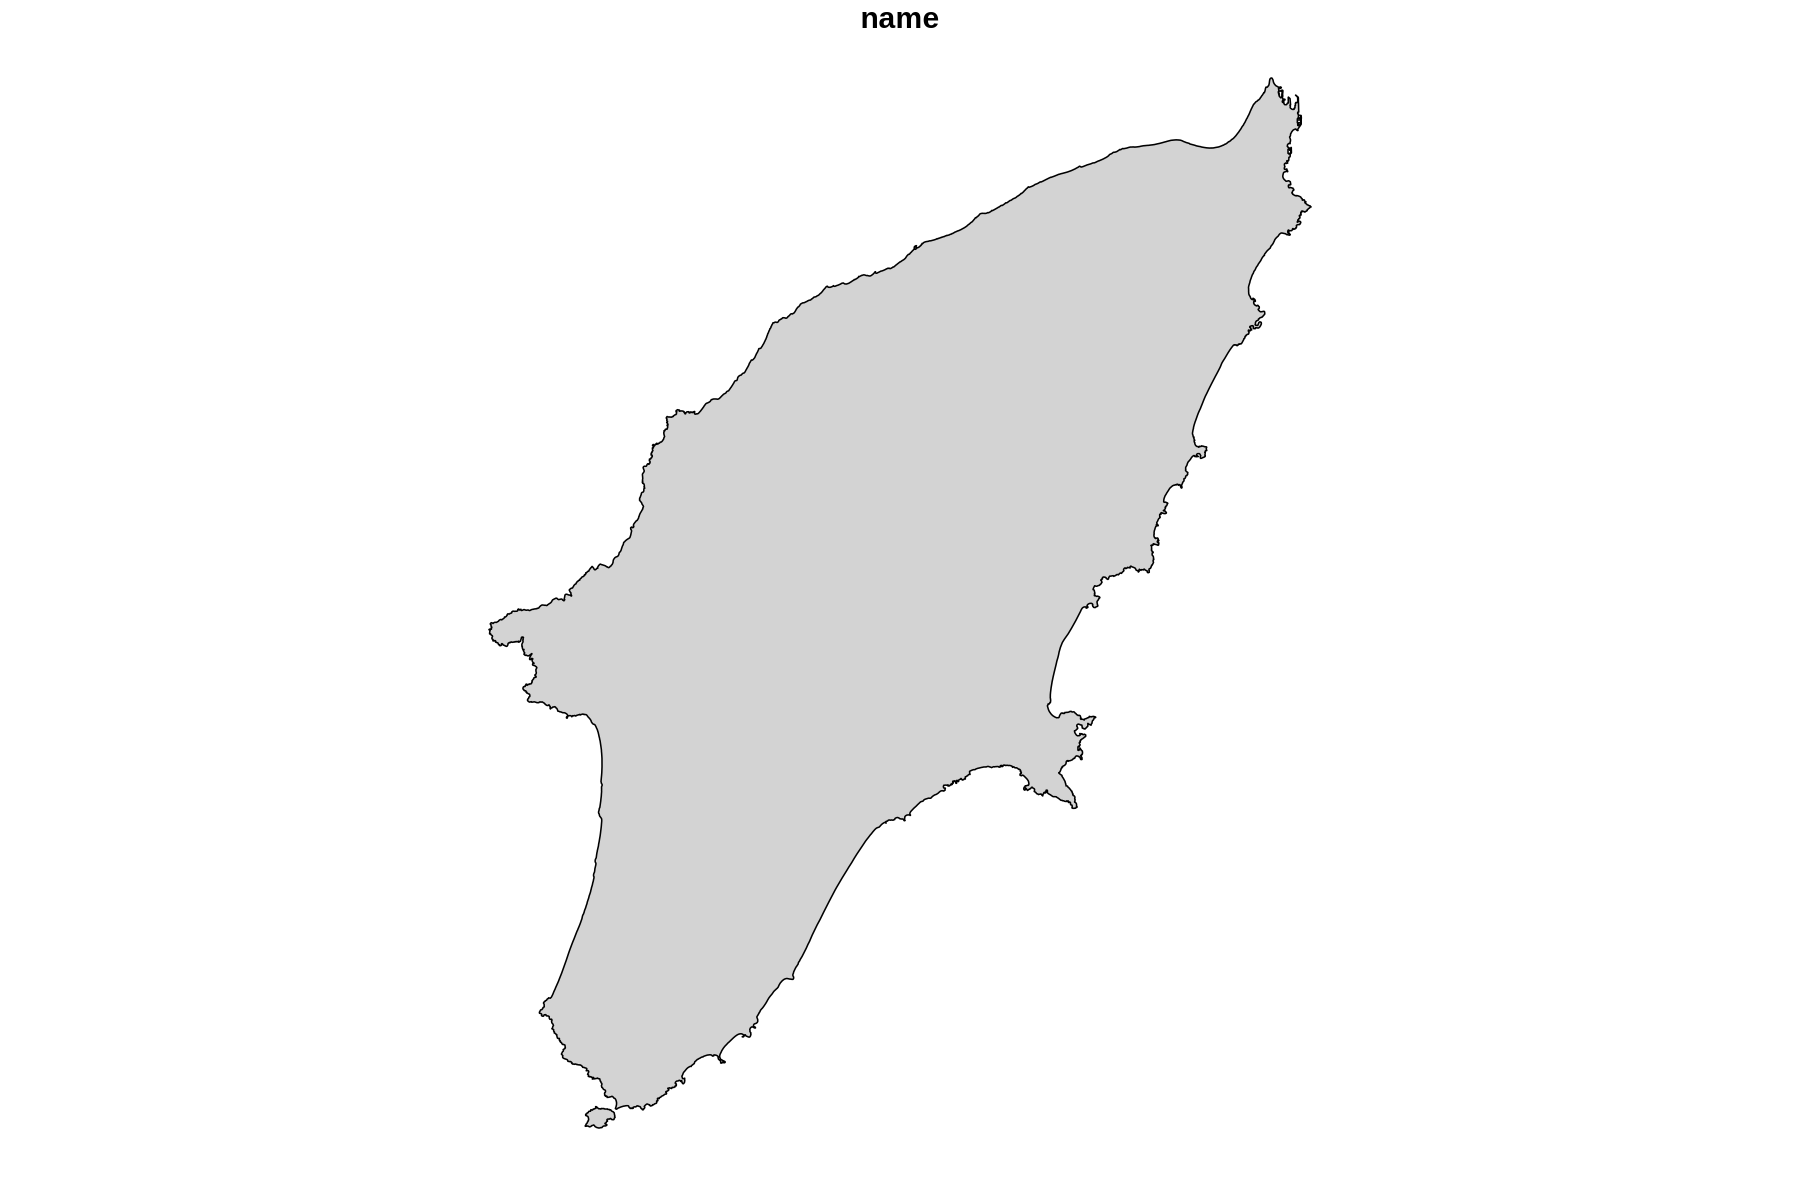

In [4]:
# Test if RoI was correctly created
roi <- st_read(roi_fn)
plot(roi["name"], col = "lightgray")

## Select and download images

In [63]:
# STAC Download Prefire Image
# NaaVRE:
#  cell:
#   outputs:
#    - dl_files_pre: String
#   cons:
#    - cons_endpoint: String
#   params:
#    - param_collection: String
#    - param_date_start: String
#    - param_date_end: String
#    - param_roi_path: String
#    - param_thresh_cloud: Integer
#    - param_date_pre: String
#    - param_bands: List
#    - param_dir_out: List
#   dependencies:
#    - name: sf
#    - name: rstac
# ...

## Load packages
library(sf)
library(rstac)

## Define a custom function to convert dates
date2rfc3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")

## Select and download STAC assets
stac_download <- function(endpoint, collection, start, end, bbox = NULL, roi_path = NULL,
                          thresh_cloud = NULL, asset_names = NULL, date = NULL, out_path = tempdir()) {

    ### Load packages
    library(sf)
    library(rstac)

    ### Format date range
    daterange <- paste(lapply(c(start, end), FUN = date2rfc3339), collapse = "/")

    ### Perform initial dataset search query
    search <- stac(endpoint) |>
      stac_search(collections = collection,
                  datetime    = daterange)
    if(!is.null(bbox)) { search <- stac_search(search, bbox = bbox) }
    if(!is.null(roi_path)) { search <- stac_search(search, intersects = st_read(roi_path, quiet = TRUE)) }
    search <- post_request(search)
    if(!is.null(thresh_cloud)) { suppressWarnings(search <- items_filter(search, properties$`eo:cloud_cover` < thresh_cloud)) }

    ### (Sub)select and fetch items
    items <- items_fetch(search, progress = FALSE)
    if(!is.null(asset_names)) { items <- assets_select(items, asset_names = asset_names) }
    if(!is.null(date)) { items <- items_select(items, selection = which(items_datetime(items) == as.Date(date))) }

    ### Download assets
    assets_json <- assets_download(items       = items,
                                   asset_names = asset_names,
                                   output_dir  = out_path,
                                   overwrite   = TRUE,
                                   use_gdal    = FALSE,
                                   progress    = FALSE)
}

## Select and download pre-fire images
dl_files_pre <- stac_download(endpoint     = cons_endpoint,
                              collection   = param_collection,
                              start        = param_date_start,
                              end          = param_date_end,
                              roi_path     = param_roi_path,
                              thresh_cloud = param_thresh_cloud,
                              asset_names  = param_bands,
                              date         = param_date_pre,
                              out_path     = param_dir_out)

In [64]:
# Check downloaded items
items_as_tibble(dl_files_pre)

constellation,created,datetime,earthsearch:boa_offset_applied,earthsearch:payload_id,earthsearch:s3_path,eo:cloud_cover,grid:code,instruments,mgrs:grid_square,⋯,s2:saturated_defective_pixel_percentage,s2:sequence,s2:snow_ice_percentage,s2:thin_cirrus_percentage,s2:unclassified_percentage,s2:vegetation_percentage,s2:water_percentage,updated,view:sun_azimuth,view:sun_elevation
<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
sentinel-2,2023-07-08T17:31:07.727Z,2023-07-08T09:00:35.241000Z,TRUE,roda-sentinel2/workflow-sentinel2-to-stac/e8620eebba2befdf91f58264cfd25877,s3://sentinel-cogs/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A,0.039288,MGRS-35SNV,msi,NV,⋯,0,0,0,0.000073,0.016608,1.552258,92.96231,2023-07-08T17:31:07.727Z,124.2712,69.20422
sentinel-2,2023-07-08T17:39:48.136Z,2023-07-08T09:00:20.745000Z,TRUE,roda-sentinel2/workflow-sentinel2-to-stac/81dbac5c25003af0bdb52f5450199e0d,s3://sentinel-cogs/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A,0.029514,MGRS-35SNA,msi,NA,⋯,0,0,0,0.000402,0.079342,10.064361,74.28475,2023-07-08T17:39:48.136Z,126.0868,68.64885
sentinel-2,2023-07-08T17:25:06.447Z,2023-07-08T09:00:17.434000Z,TRUE,roda-sentinel2/workflow-sentinel2-to-stac/ac38f8969beaec4e7156fff4695a26ba,s3://sentinel-cogs/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A,1.655831,MGRS-35SPA,msi,PA,⋯,0,0,0,0.027568,0.230888,21.613187,61.46569,2023-07-08T17:25:06.447Z,128.1200,69.36429


In [68]:
# STAC Download Postfire Image
# NaaVRE:
#  cell:
#   outputs:
#    - dl_files_post: String
#   cons:
#    - cons_endpoint: String
#   params:
#    - param_collection: String
#    - param_date_start: String
#    - param_date_end: String
#    - param_roi_path: String
#    - param_thresh_cloud: Integer
#    - param_date_post: String
#    - param_bands: List
#    - param_dir_out: List
#   dependencies:
#    - name: sf
#    - name: rstac
# ...

## Load packages
library(sf)
library(rstac)

## Define a custom function to convert dates
date2rfc3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")

## Select and download STAC assets
stac_download <- function(endpoint, collection, start, end, bbox = NULL, roi_path = NULL,
                          thresh_cloud = NULL, asset_names = NULL, date = NULL, out_path = tempdir()) {

    ### Load packages
    library(sf)
    library(rstac)

    ### Format date range
    daterange <- paste(lapply(c(start, end), FUN = date2rfc3339), collapse = "/")

    ### Perform initial dataset search query
    search <- stac(endpoint) |>
      stac_search(collections = collection,
                  datetime    = daterange)
    if(!is.null(bbox)) { search <- stac_search(search, bbox = bbox) }
    if(!is.null(roi_path)) { search <- stac_search(search, intersects = st_read(roi_path, quiet = TRUE)) }
    search <- post_request(search)
    if(!is.null(thresh_cloud)) { suppressWarnings(search <- items_filter(search, properties$`eo:cloud_cover` < thresh_cloud)) }

    ### (Sub)select and fetch items
    items <- items_fetch(search, progress = FALSE)
    if(!is.null(asset_names)) { items <- assets_select(items, asset_names = asset_names) }
    if(!is.null(date)) { items <- items_select(items, selection = which(items_datetime(items) == as.Date(date))) }

    ### Download assets
    assets_json <- assets_download(items       = items,
                                   asset_names = asset_names,
                                   output_dir  = out_path,
                                   overwrite   = TRUE,
                                   use_gdal    = FALSE,
                                   progress    = FALSE)
}

## Select and download pre-fire images
dl_files_post <- stac_download(endpoint     = cons_endpoint,
                               collection   = param_collection,
                               start        = param_date_start,
                               end          = param_date_end,
                               roi_path     = param_roi_path,
                               thresh_cloud = param_thresh_cloud,
                               asset_names  = param_bands,
                               date         = param_date_post,
                               out_path     = param_dir_out)

In [69]:
# Check downloaded items
items_as_tibble(dl_files_post)

<0 x 0 matrix>

In [71]:
print(list.files(path = param_dir_out, pattern = "*.tif", full.names = TRUE, recursive = TRUE))

 [1] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif"
 [2] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif"
 [3] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif"
 [4] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif"
 [5] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif"
 [6] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif"
 [7] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif"
 [8] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif"
 [9] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif"
[10] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif"
[11] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L

### Mosaic pre- and post-fire images

The three scenes/tiles have to be merged into one image for each of pre- and post-fire:

In [37]:
## Group images according to date
group <- lapply(strsplit(dl_files, split = "/"),
                FUN = function(x) x[9]) |>
            unlist() |>
            as.factor()

## Group images according to tile
tile <- lapply(strsplit(dl_files, split = "/"),
               FUN = function(x) x[7]) |>
            unlist() |>
            as.factor()

dl_files_sep <- strsplit(dl_files, split = "/")
dl_files_df <- as.data.frame(do.call(rbind, lapply(dl_files_sep, rbind)))
names(dl_files_df) <- c("root", "base", "sub", "collection", "zone", "area", "tile", "year", "month")
print(dl_files_df)

   V1  V2         V3                   V4 V5 V6 V7   V8 V9
1     tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S NA 2023  7
2     tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S NA 2023  7
3     tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S NA 2023  8
4     tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S NA 2023  8
5     tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S NV 2023  7
6     tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S NV 2023  7
7     tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S NV 2023  8
8     tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S NV 2023  8
9     tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S PA 2023  7
10    tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S PA 2023  7
11    tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S PA 2023  8
12    tmp RtmpL9Vv20 sentinel-s2-l2a-cogs 35  S PA 2023  8
                        V10     V11
1  S2A_35SNA_20230708_0_L2A B12.tif
2  S2A_35SNA_20230708_0_L2A B8A.tif
3  S2A_35SNA_20230827_0_L2A B12.tif
4  S2A_35SNA_20230827_0_L2A B8A.tif
5  S2A_35SNV_20230708_0_L2A B12.tif
6  S2A_35SNV_2023

In [29]:


## Apply grouping
pre_list <- dl_files[group == "7"]
post_list <- dl_files[group == "8"]
               
cat("\nPre-fire image files:\n\n")
print(pre_list)

cat("\n\nPost-fire image files:\n\n")
print(post_list)


Pre-fire image files:

[1] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif"
[2] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif"
[3] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif"
[4] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif"
[5] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif"
[6] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif"


Post-fire image files:

[1] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif"
[2] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif"
[3] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif"
[4] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif"
[5] "/tmp/RtmpL9Vv20/sentinel-s2-l2a-cog

In [ ]:
s2_pre_path <- "./mosaics/s2_pre.tif"
merge(x = rast(pre_na_list), y = rast(pre_nv_list), z = rast(pre_pa_list),
      filename = s2_pre_path, overwrite = TRUE)
gc()